<a href="https://colab.research.google.com/github/Minakshi654/DocSense--CNN-based-Document-Classifier/blob/main/CNN_for_coco_cola.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())

import os
os.environ['KAGGLE_USERNAME'] = "Mina26052001"
os.environ['KAGGLE_KEY'] = "KGAT_489ce73d1954fddf31a7220f42233c7f"

!pip install kaggle -q
print("Kaggle credentials set")

GPU available: True
Kaggle credentials set


In [ ]:
!kaggle datasets download -d marquis03/supermarket-shelves

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata


In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:02<00:00, 170MB/s]



In [ ]:
!kaggle datasets download -d validmodel/grocery-store-dataset

Dataset URL: https://www.kaggle.com/datasets/validmodel/grocery-store-dataset
License(s): other
100% 118M/118M [00:01<00:00, 98.0MB/s]



In [ ]:
!unzip -q -o grocery-store-dataset.zip -d grocery_data
!ls grocery_data

GroceryStoreDataset


In [ ]:
!ls grocery_data/GroceryStoreDataset

dataset  sample_images


In [ ]:
!ls grocery_data/GroceryStoreDataset/dataset

classes.csv			test	  train      val
iconic-images-and-descriptions	test.txt  train.txt  val.txt


In [ ]:
import pandas as pd

classes_df = pd.read_csv("grocery_data/GroceryStoreDataset/dataset/classes.csv")
print(classes_df.shape)
print(classes_df.head(20))
print("\nColumns:", classes_df.columns.tolist())

(81, 6)
    Class Name (str)  Class ID (int) Coarse Class Name (str)  \
0   Golden-Delicious               0                   Apple   
1       Granny-Smith               1                   Apple   
2          Pink-Lady               2                   Apple   
3      Red-Delicious               3                   Apple   
4         Royal-Gala               4                   Apple   
5            Avocado               5                 Avocado   
6             Banana               6                  Banana   
7               Kiwi               7                    Kiwi   
8              Lemon               8                   Lemon   
9               Lime               9                    Lime   
10             Mango              10                   Mango   
11        Cantaloupe              11                   Melon   
12       Galia-Melon              12                   Melon   
13    Honeydew-Melon              13                   Melon   
14        Watermelon            

In [ ]:
print(classes_df["Coarse Class Name (str)"].unique())
print("\nTotal coarse classes:", classes_df["Coarse Class Name (str)"].nunique())

# Count how many fine-grained classes and how many images roughly fall under each coarse class
print("\nFine classes per coarse class:")
print(classes_df.groupby("Coarse Class Name (str)").size().sort_values(ascending=False))

['Apple' 'Avocado' 'Banana' 'Kiwi' 'Lemon' 'Lime' 'Mango' 'Melon'
 'Nectarine' 'Orange' 'Papaya' 'Passion-Fruit' 'Peach' 'Pear' 'Pineapple'
 'Plum' 'Pomegranate' 'Red-Grapefruit' 'Satsumas' 'Juice' 'Milk'
 'Oatghurt' 'Oat-Milk' 'Sour-Cream' 'Sour-Milk' 'Soyghurt' 'Soy-Milk'
 'Yoghurt' 'Asparagus' 'Aubergine' 'Cabbage' 'Carrots' 'Cucumber' 'Garlic'
 'Ginger' 'Leek' 'Mushroom' 'Onion' 'Pepper' 'Potato' 'Red-Beet' 'Tomato'
 'Zucchini']

Total coarse classes: 43

Fine classes per coarse class:
Coarse Class Name (str)
Juice             10
Yoghurt            6
Milk               6
Apple              5
Pepper             4
Melon              4
Pear               3
Potato             3
Tomato             3
Sour-Cream         2
Soyghurt           2
Soy-Milk           2
Ginger             1
Cucumber           1
Carrots            1
Banana             1
Cabbage            1
Avocado            1
Aubergine          1
Asparagus          1
Garlic             1
Kiwi               1
Leek               

In [ ]:
train_list = pd.read_csv(
    "grocery_data/GroceryStoreDataset/dataset/train.txt",
    header=None,
    names=["path", "fine_label", "coarse_label"]
)
val_list = pd.read_csv(
    "grocery_data/GroceryStoreDataset/dataset/val.txt",
    header=None,
    names=["path", "fine_label", "coarse_label"]
)
test_list = pd.read_csv(
    "grocery_data/GroceryStoreDataset/dataset/test.txt",
    header=None,
    names=["path", "fine_label", "coarse_label"]
)

print(train_list.shape, val_list.shape, test_list.shape)
print(train_list.head())

(2640, 3) (296, 3) (2485, 3)
                                                path  fine_label  coarse_label
0  train/Fruit/Apple/Golden-Delicious/Golden-Deli...           0             0
1  train/Fruit/Apple/Golden-Delicious/Golden-Deli...           0             0
2  train/Fruit/Apple/Golden-Delicious/Golden-Deli...           0             0
3  train/Fruit/Apple/Golden-Delicious/Golden-Deli...           0             0
4  train/Fruit/Apple/Golden-Delicious/Golden-Deli...           0             0


In [ ]:
# Get the coarse class IDs for our 4 chosen categories
target_coarse_names = ["Juice", "Milk", "Apple", "Tomato"]

# Build a mapping: coarse name -> coarse ID (using our classes_df from earlier)
coarse_id_map = classes_df.drop_duplicates("Coarse Class Name (str)").set_index("Coarse Class Name (str)")["Coarse Class ID (int)"].to_dict()

target_ids = {name: coarse_id_map[name] for name in target_coarse_names}
print("Target class IDs:", target_ids)

# Filter each split to only our 4 classes
target_id_values = list(target_ids.values())

train_filtered = train_list[train_list["coarse_label"].isin(target_id_values)].reset_index(drop=True)
val_filtered = val_list[val_list["coarse_label"].isin(target_id_values)].reset_index(drop=True)
test_filtered = test_list[test_list["coarse_label"].isin(target_id_values)].reset_index(drop=True)

print("\nTrain:", train_filtered.shape)
print("Val:", val_filtered.shape)
print("Test:", test_filtered.shape)

print("\nClass distribution in train:")
print(train_filtered["coarse_label"].value_counts())

Target class IDs: {'Juice': 19, 'Milk': 20, 'Apple': 0, 'Tomato': 41}

Train: (834, 3)
Val: (85, 3)
Test: (759, 3)

Class distribution in train:
coarse_label
0     278
19    247
20    182
41    127
Name: count, dtype: int64


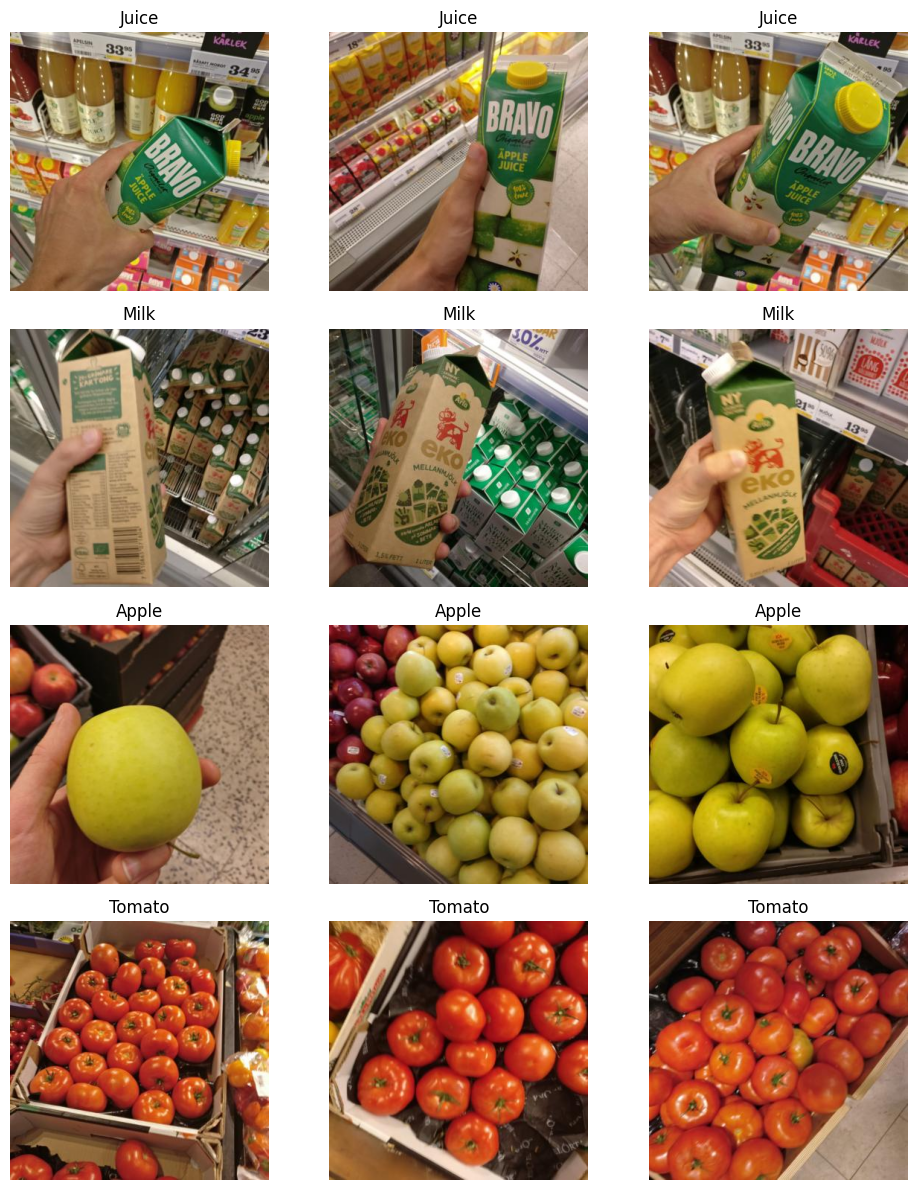

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

base_path = "grocery_data/GroceryStoreDataset/dataset/"

fig, axes = plt.subplots(4, 3, figsize=(10, 12))

for row, (class_name, class_id) in enumerate(target_ids.items()):
    class_samples = train_filtered[train_filtered["coarse_label"] == class_id].head(3)

    for col in range(3):
        img_path = base_path + class_samples.iloc[col]["path"]
        img = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),       # grocery items can appear facing either way on shelf
    transforms.RandomRotation(10),           # handheld photos are rarely perfectly level
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # different store lighting conditions
    transforms.ToTensor(),
])

class GroceryDataset(Dataset):
    def __init__(self, df, base_path, target_ids, transform):
        self.df = df
        self.base_path = base_path
        self.transform = transform
        self.label_map = {orig_id: new_id for new_id, orig_id in enumerate(target_ids.values())}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.base_path + row["path"]).convert("RGB")
        img = self.transform(img)
        label = self.label_map[row["coarse_label"]]
        return img, label

train_dataset = GroceryDataset(train_filtered, base_path, target_ids, train_transform)
val_dataset = GroceryDataset(val_filtered, base_path, target_ids, transform)
test_dataset = GroceryDataset(test_filtered, base_path, target_ids, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 53
Val batches: 6
Test batches: 48


In [ ]:
import torch.nn as nn
from torchvision import models

# Load ResNet18 pretrained on ImageNet
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all the pretrained layers - we don't want to destroy what it already learned
for param in resnet.parameters():
    param.requires_grad = False

# Replace the final classification layer with one for our 4 classes
# (ResNet18's original final layer outputs 1000 classes - ImageNet's categories - we need just 4)
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet = resnet.to(device)

print(resnet.fc)
print("\nTrainable parameters:", sum(p.numel() for p in resnet.parameters() if p.requires_grad))
print("Total parameters:", sum(p.numel() for p in resnet.parameters()))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


Linear(in_features=512, out_features=4, bias=True)

Trainable parameters: 2052
Total parameters: 11178564


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=0.001)  # only optimize the unfrozen layer

num_epochs = 15
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    resnet.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    resnet.eval()
    val_correct, val_total, val_running_loss = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}%  |  Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

Epoch [1/15]  Train Loss: 0.8564 Acc: 66.43%  |  Val Loss: 0.5692 Acc: 77.65%
Epoch [2/15]  Train Loss: 0.4482 Acc: 86.33%  |  Val Loss: 0.4408 Acc: 82.35%
Epoch [3/15]  Train Loss: 0.3428 Acc: 89.57%  |  Val Loss: 0.3189 Acc: 87.06%
Epoch [4/15]  Train Loss: 0.3064 Acc: 90.17%  |  Val Loss: 0.3659 Acc: 84.71%
Epoch [5/15]  Train Loss: 0.2696 Acc: 91.01%  |  Val Loss: 0.2504 Acc: 91.76%
Epoch [6/15]  Train Loss: 0.2223 Acc: 93.65%  |  Val Loss: 0.2246 Acc: 92.94%
Epoch [7/15]  Train Loss: 0.2178 Acc: 93.29%  |  Val Loss: 0.2143 Acc: 94.12%
Epoch [8/15]  Train Loss: 0.2458 Acc: 92.45%  |  Val Loss: 0.2319 Acc: 91.76%
Epoch [9/15]  Train Loss: 0.2198 Acc: 93.53%  |  Val Loss: 0.2022 Acc: 94.12%
Epoch [10/15]  Train Loss: 0.1808 Acc: 94.48%  |  Val Loss: 0.1902 Acc: 92.94%
Epoch [11/15]  Train Loss: 0.1877 Acc: 93.17%  |  Val Loss: 0.1995 Acc: 92.94%
Epoch [12/15]  Train Loss: 0.1859 Acc: 94.48%  |  Val Loss: 0.2440 Acc: 90.59%
Epoch [13/15]  Train Loss: 0.1825 Acc: 94.24%  |  Val Loss: 0

Test Accuracy: 91.17%


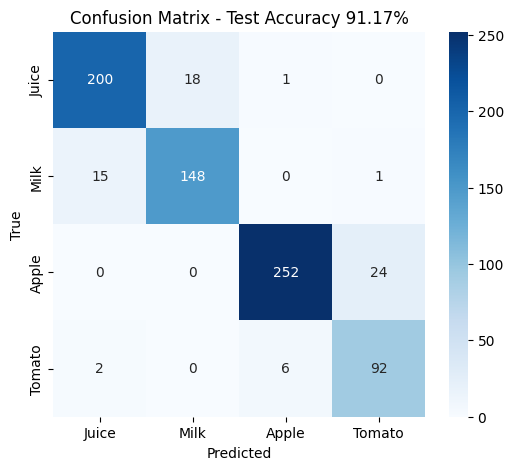

              precision    recall  f1-score   support

       Juice       0.92      0.91      0.92       219
        Milk       0.89      0.90      0.90       164
       Apple       0.97      0.91      0.94       276
      Tomato       0.79      0.92      0.85       100

    accuracy                           0.91       759
   macro avg       0.89      0.91      0.90       759
weighted avg       0.92      0.91      0.91       759



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

resnet.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {test_accuracy:.2f}%")

class_names = list(target_ids.keys())
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix - Test Accuracy {test_accuracy:.2f}%")
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

In [ ]:
torch.save(resnet.state_dict(), "grocery_compliance_resnet18.pth")

from google.colab import files
files.download("grocery_compliance_resnet18.pth")

print("Model saved")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model saved


# Component 2 — Retail Compliance Classifier (CNN, Transfer Learning)

Part of the Coca-Cola Demand Intelligence & Market Insights Platform. A transfer-learning image classifier that categorizes in-store shelf photos into product categories — the foundational step for automated retail compliance/shelf auditing, a real task performed by market research firms like Kantar.

## Objective

Classify real, in-the-wild grocery shelf photographs into product categories (Juice, Milk, Apple, Tomato), using transfer learning rather than training from scratch — directly addressing a limitation identified in a prior from-scratch CNN project (DocSense), where training every parameter from zero led to overfitting on a small dataset.

## Dataset

- **Source:** Kaggle — "Grocery Store Dataset" (`validmodel/grocery-store-dataset`), originally presented in a WACV 2019 paper ("A Hierarchical Grocery Store Image Dataset with Visual and Semantic Labels")
- **Real, in-the-wild images:** smartphone photos taken in actual grocery stores, including hand-held products against shelf backgrounds, price tags, and realistic lighting/angle variation
- **Classes selected:** Juice (beverage category, directly relevant to the platform's Coca-Cola/beverage narrative), Milk (a visually similar packaged-drink category for contrast), Apple and Tomato (fresh produce categories, visually distinct from packaged beverages)
- **Official train/val/test splits used** (as defined by the dataset authors): 834 train / 85 validation / 759 test images across the 4 selected classes

## Approach

- **Transfer learning with ResNet18:** rather than training a CNN from scratch (as in a prior project), the entire pretrained ResNet18 backbone (trained on 1.4M ImageNet images) was frozen, and only the final classification layer was replaced and trained for the 4 target classes
- **Trainable parameters: 2,052 out of 11,178,564 total — 0.018%** of the network
- **Data augmentation applied proactively from the start** (random horizontal flip, rotation, color jitter) rather than added reactively after observing overfitting, reflecting a lesson carried forward from an earlier project
- **Validation tracked every epoch** to monitor train/validation divergence in real time

## Results

- **Test accuracy: 91.17%** — notably consistent with (and slightly exceeding) validation accuracy during training, confirming genuine generalization rather than overfitting
- Per-class F1-scores ranged from 0.85 (Tomato) to 0.94 (Apple), with all 4 classes performing strongly

| Class | Precision | Recall | F1-score |
|---|---|---|---|
| Juice | 0.92 | 0.91 | 0.92 |
| Milk | 0.89 | 0.90 | 0.90 |
| Apple | 0.97 | 0.91 | 0.94 |
| Tomato | 0.79 | 0.92 | 0.85 |

## Key finding — confirmed visual hypothesis before training

Before training, manual inspection of sample images revealed that Juice and Milk products shared similar green packaging and nearly identical photo composition (hand-held cartons against a shelf background). This hypothesis was directly confirmed by the confusion matrix: Juice↔Milk accounted for the largest share of misclassifications (18 and 15 images respectively). A secondary, unanticipated confusion pattern also emerged between Apple and Tomato (both round, similarly-sized produce items). Critically, near-zero cross-confusion occurred between the beverage classes and the produce classes — confirming the model learned a clean, sensible high-level distinction (packaged goods vs. fresh produce), with remaining errors concentrated at a finer visual-similarity level within each pair.

## Comparison to prior from-scratch CNN project

| Metric | From-scratch CNN (prior project) | Transfer learning (this project) |
|---|---|---|
| Trainable parameters | 100% of model | 0.018% of model |
| Training images | 384 | 834 |
| Test accuracy | 70.83% | 91.17% |
| Train/test accuracy gap | Required dropout + augmentation to control; still ~12 points | Consistently ~1-3 points throughout training |

This comparison directly demonstrates the practical value of transfer learning when working with limited domain-specific data — a real, common constraint in applied computer vision work.

## What I'd improve next

- Unfreeze and fine-tune the last few ResNet18 layers (rather than only the final classifier) with a low learning rate, to adapt mid-level visual features specifically to grocery/retail imagery
- Expand to more coarse classes to build a fuller retail-category compliance system
- Add object detection (not just whole-image classification) to identify multiple products and their shelf positions within a single photo, closer to real planogram compliance auditing

## Tech stack

`Python` · `PyTorch` · `torchvision` (ResNet18, pretrained weights) · `pandas` · `scikit-learn` · `seaborn` · Kaggle API · Google Colab (T4 GPU)

## How to run

1. Open `02_coca_cola_shelf_compliance_cnn.ipynb` in Google Colab
2. Add your Kaggle API credentials
3. Run all cells in order